# ITER Flattop — TokaMaker_TORAX

Simulates the ITER H-mode flattop at 15 MA using TokaMaker_TORAX.

2026-06-02 v1 F. Sheehan - Creation


# 0. Introduction

This notebook sets up and runs a time dependent simulation of an ITER flattop scenario using the TokaMaker+TORAX workflow. [TokaMaker](https://github.com/OpenFUSIONToolkit/OpenFUSIONToolkit) (TM) is a time-**independent** (steady state) Grad-Shafranov MHD equilibrium solver available through the OpenFUSIONToolkit suite of open source tools. Being familiar with TokaMaker is highly recommended before proceeding. The [Build your own tokamak](https://fusion.columbia.edu/build-your-own-tokamak) project available through the Columbia Fusion Research Center Outreach website is a great way to become familiar with TokaMaker. 

[TORAX](https://github.com/google-deepmind/torax) (TX) is a time-**dependent** transport solver developed by Google DeepMind. It solves the fluid transport equations to model how temperature (thermal energy), current, and density move through the plasma over time. Both codes are entirely open source and available on Github. 

The TM+TX workflow couples these two codes and produces a time dependent solution for the radial kinetic (temperature and density) and current profiles on a realistic geometry (the equilibrium solution from TM). TM+TX passes the results of these two codes back and forth over several (2-4) loops until they converge.

This simulation uses the `steady_state_mode` of TM+TX which uses the time dependent nature of TORAX to allow initial profile inputs (guesses) to "relax" into more realistic forms and produces a steady state solution. No inputs vary over time, so the end result is a stationary (steady-state) solution. For this case we will use a full power, full current, ITER flattop scenario.

The notebook is in a working state using a default configuration. The goal of this project is to change inputs and see the effect on the equilibrated flattop plasma state and performance.

TM/TX version:

This simulation works with the following package versions:
torax: 1.4.0
OFT: Latest merge 2026-06-04

## 1. Imports and environment setup

In [1]:
# import os
# import shutil
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from time import perf_counter


plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['lines.linewidth'] = 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.pulse_design import TokaMaker_TORAX
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import create_power_flux_fun
from omfit_classes.utils_fusion import Hmode_profiles

# Clear jax_cache to avoid semaphore leaks between runs
# _jax_cache = Path('/Users/fsheehan/jax_cache')
# if _jax_cache.exists():
#     for item in _jax_cache.iterdir():
#         shutil.rmtree(item) if item.is_dir() else item.unlink()


## 2. Device parameters and simulation timing

Based on values from Fitzpatrick 2026 Nuclear Fusion (which is in turn based on several other full power, ITER H-mode pulse designs).

| Parameter | Value | Note |
|-----------|-------|------|
| R0 | 6.2 m | Major radius |
| B0 | 5.3 T | On-axis toroidal field |
| Ip | 15 MA | Full ITER design current |
| κ | 1.7 | Elongation |
| δ | 0.4 | Triangularity |

In [2]:
NOTEBOOK_DIR = Path('.').resolve()
MESH_H5 = NOTEBOOK_DIR / 'ITER_mesh.h5' # the ITER_mesh.h5 files should be in the same directory as this notebook.

# Scalar inputs
R0      = 6.2    # m, major radius
B0      = 5.3    # T, on-axis toroidal field
Z0      = 0.5    # m, vertical centering on TokaMaker grid
A_FLAT  = 2.0    # m, minor radius
KAPPA   = 1.7    # elongation
DELTA   = 0.4    # triangularity

IP_FLAT = 15.0e6  # Amps

# TokaMaker_TORAX simulation length (long enough to equilibrate)
T_FINAL     = 100.0  # s

# Pedestal / density reference
NE_FLAT    = 1.0e20   # m^-3
ZEFF       = 1.7 # effective ion charge, proxy for impurity content

## 3. ITER lower single-null geometry

ITER uses a diverted geometry with a single X-point (poloidal field null) at the bottom of the plasma. The X-point and isoflux points (the targets for the edge of the plasma, called the last closed flux surface or LCFS) should be left alone.

In [3]:
##### DO NOT CHANGE #####
# Lower single-null X-point
X_POINTS = np.array([[5.125, -3.4]])

# Fixed asymmetric LCFS isoflux points (LSN, from rampdown flat_start seed)
DIVERTED_ISOFLUX_PTS = np.array([
    [8.20,  0.41],
    [8.06,  1.46],
    [7.51,  2.62],
    [6.14,  3.78],
    [5.10,  3.72],
    [4.51,  3.02],
    [4.26,  1.33],
    [4.28,  0.08],
    [4.49, -1.34],
    [7.28, -1.89],
    [8.00, -0.68],
])
##### DO NOT CHANGE #####


## 4. TokaMaker setup

Initialise the Grad-Shafranov solver TokaMaker object with the ITER mesh. The TokaMaker object is used to generate the seed equilibrium then passed to the TokaMaker_TORAX simulation. This also gives limits to the poloidal field (PF) and center stack (CS) coil limits.

In [4]:
##### DO NOT CHANGE #####
myOFT = OFT_env(nthreads=4)
mygs  = TokaMaker(myOFT)

mesh_pts, mesh_lc, mesh_reg, coil_dict, cond_dict = load_gs_mesh(str(MESH_H5))
mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)
mygs.setup_regions(cond_dict=cond_dict, coil_dict=coil_dict)
mygs.settings.maxits = 100
mygs.setup(order=2, F0=R0 * B0)

mygs.set_coil_vsc({'VS': 1.0})

coil_bounds = {key: [-50.0e6, 50.0e6] for key in mygs.coil_sets}
mygs.set_coil_bounds(coil_bounds)
reg_terms = []
for name in mygs.coil_sets:
    if name.startswith('CS'):
        w = 2.0e-2 if name.startswith('CS1') else 1.0e-2
        reg_terms.append(mygs.coil_reg_term({name: 1.0}, target=0.0, weight=w))
    elif name.startswith('PF'):
        reg_terms.append(mygs.coil_reg_term({name: 1.0}, target=0.0, weight=1.0e-2))
    elif name.startswith('VS'):
        reg_terms.append(mygs.coil_reg_term({name: 1.0}, target=0.0, weight=1.0e-2))
reg_terms.append(mygs.coil_reg_term({'#VSC': 1.0}, target=0.0, weight=1.0e2))
mygs.set_coil_reg(reg_terms=reg_terms)
##### DO NOT CHANGE #####

#----------------------------------------------
Open FUSION Toolkit Initialized
Development branch:    tmtx_updates_1
Revision id:           22e8b4e
Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    4
Integer Precisions    =    4   8
Float Precisions      =    4   8  16
Complex Precisions    =    4   8
LA backend            = native
#----------------------------------------------


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  2.859E+02
    # of points  =    4757
    # of edges   =   14156
    # of cells   =    9400
    # of boundary points =     112
    # of boundary edges  =     112
    # of boundary cells  =     112
  Resolution statistics:
    hmin =  9.924E-03
    hrms =  2.826E-01
    hmax =  8.466E-01
  Surface grounded at vertex     870


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Computing flux BC matrix 
 Inverting real matrix
   Tim

## 5. Initial equilibrium

Solve a single inverse equilibrium at full ITER flattop conditions.
The H-mode current/pressure profile shapes `(α, γ) = (1.5, 2.0)` for FF' and
`(2.0, 1.5)` for P' are the same as in the rampdown script.

In [5]:
# H-mode-like profile shapes
ffp_prof = create_power_flux_fun(40, 1.5, 2.0)
pp_prof  = create_power_flux_fun(40, 2.0, 1.5)
mygs.set_profiles(ffp_prof=ffp_prof, pp_prof=pp_prof)

# Peak pressure at flattop: 2 * ne * Te_core
TE_CORE_KEV = 20.0
pax_flat = 2.0 * NE_FLAT * TE_CORE_KEV * 1e3 * 1.602e-19
print(f'Target pax = {pax_flat/1e3:.1f} kPa')

Target pax = 640.8 kPa


In [6]:
# Set shape constraints (LSN diverted)
mygs.set_saddle_constraints(X_POINTS)
mygs.set_isoflux_constraints(DIVERTED_ISOFLUX_PTS)

isoflux_weights = np.full(DIVERTED_ISOFLUX_PTS.shape[0], 10.0)
isoflux_targets = np.zeros(DIVERTED_ISOFLUX_PTS.shape[0])
mygs.set_psi_constraints(DIVERTED_ISOFLUX_PTS, isoflux_targets, weights=isoflux_weights)

# build_min_norm_coil_reg(mygs)
mygs.set_targets(Ip=IP_FLAT, pax=pax_flat)
mygs.init_psi(R0, Z0, A_FLAT, KAPPA, DELTA)
mygs.solve()
mygs.print_info()

Starting non-linear GS solver
     1  8.2251E+00  1.7033E-01  6.0508E-01  6.4217E+00  5.3467E-01 -2.2681E-05
     2  1.6251E+01  1.1444E-01  2.4854E-01  6.4017E+00  5.3975E-01 -3.9783E-05
     3  1.9147E+01  1.0106E-01  1.2064E-01  6.3883E+00  5.4344E-01  3.1314E-05
     4  2.0602E+01  9.6166E-02  7.3133E-02  6.3807E+00  5.4577E-01  1.1092E-04
     5  2.1429E+01  9.3894E-02  4.7468E-02  6.3763E+00  5.4719E-01  1.7559E-04
     6  2.1921E+01  9.2685E-02  3.0759E-02  6.3738E+00  5.4800E-01  2.2146E-04
     7  2.2220E+01  9.1992E-02  1.9663E-02  6.3724E+00  5.4844E-01  2.5199E-04
     8  2.2402E+01  9.1582E-02  1.2439E-02  6.3715E+00  5.4866E-01  2.7174E-04
     9  2.2514E+01  9.1334E-02  7.8043E-03  6.3710E+00  5.4876E-01  2.8426E-04
    10  2.2583E+01  9.1184E-02  4.8813E-03  6.3707E+00  5.4880E-01  2.9209E-04
    11  2.2625E+01  9.1092E-02  3.0455E-03  6.3705E+00  5.4880E-01  2.9697E-04
    12  2.2651E+01  9.1036E-02  1.8977E-03  6.3704E+00  5.4878E-01  2.9999E-04
    13  2.2666E+01  9.

Saving gEQDSK: /Users/fsheehan/github/TokaMaker_TORAX_project/ITER_flattop_seed.eqdsk
 Using COCOS=2...
Saved: ITER_flattop_seed.eqdsk


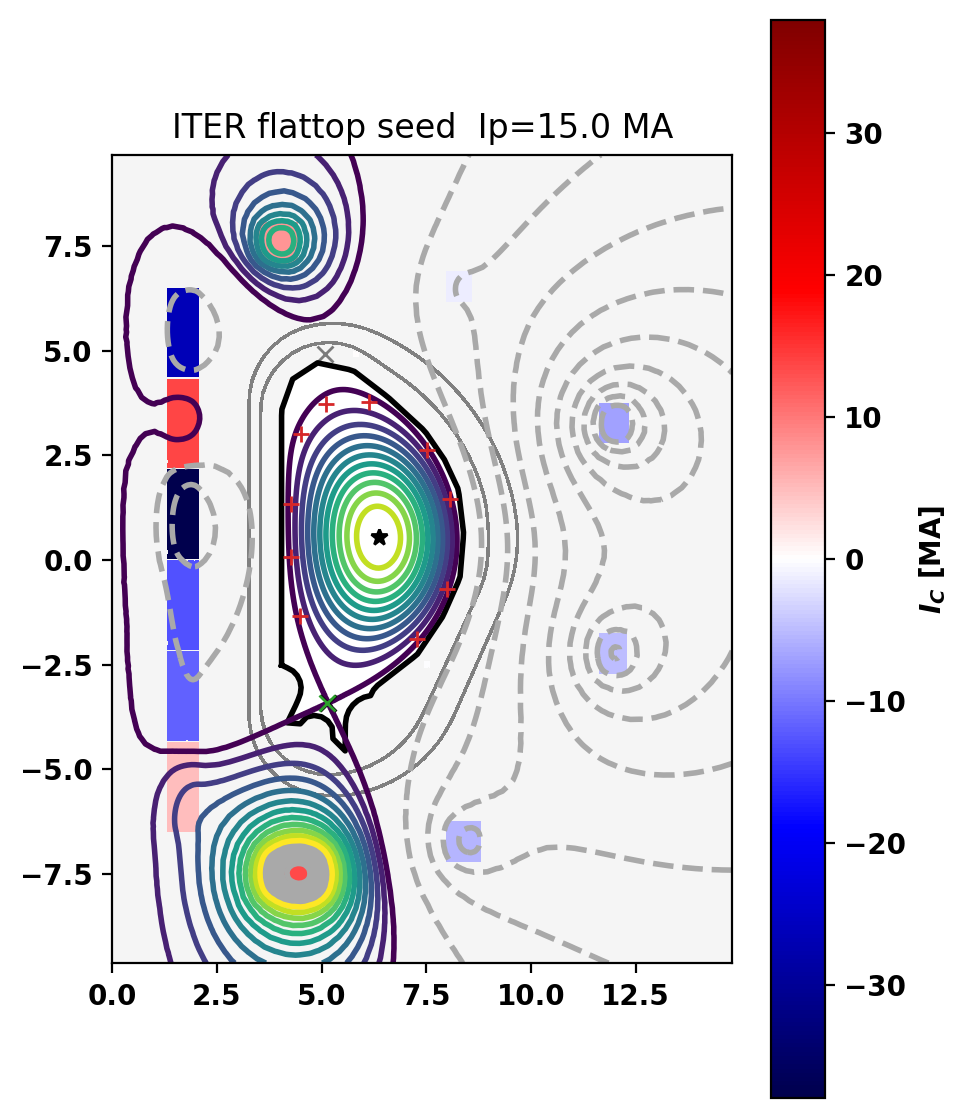

In [7]:
# Save eqdsk and plot
eqdsk_path = NOTEBOOK_DIR / 'ITER_flattop_seed.eqdsk'
mygs.save_eqdsk(str(eqdsk_path), cocos=2, nr=750, nz=750)
print(f'Saved: {eqdsk_path.name}')

fig, ax = plt.subplots(1, 1, figsize=(5, 7))
mygs.plot_machine(fig, ax, coil_colormap='seismic', coil_scale=1.0e-6,
                  coil_clabel=r'$I_C$ [MA]', coil_symmap=True)
mygs.plot_psi(fig, ax, plasma_nlevels=12, vacuum_nlevels=10)
mygs.plot_constraints(fig, ax)
ax.set_title(f'ITER flattop seed  Ip={IP_FLAT/1e6:.1f} MA')
fig.savefig(NOTEBOOK_DIR / 'ITER_flattop_seed_eqdsk.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. TokaMaker_TORAX coupling

Because the equilibrium is held fixed at flattop, both `eqtimes` and
`g_eqdsk_arr` reference the single seed eqdsk at the start and end of the
simulation window.

In [8]:
tm_times = np.linspace(0, T_FINAL, 3)

tmtx = TokaMaker_TORAX(
    t_init=0,
    t_final=T_FINAL,
    tx_dt=0.5,
    eqtimes=np.array([0, T_FINAL]),
    g_eqdsk_arr=[str(eqdsk_path), str(eqdsk_path)],
    last_surface_factor=0.9999,
    tm_times=tm_times,
    tokamaker_obj=mygs,
)

## 7. TORAX configuration

In [9]:
tmtx.set_TORAX_grid(grid_type='n_rho', grid=51)

## 8. Heating and fueling

ITER flattop heating is primarily alpha-heated, supplemented by modest ECRH and
NBI. Values are taken from the rampdown script's flat-start heating schedule:

| Source | Power | Location (ρ) |
|--------|-------|-------------|
| ECRH   | 3 MW  | 0.4 (off-axis) |
| NBI    | 5 MW  | 0.5 (off-axis) |

In [10]:
P_ECRH = 3.0e6   # W
P_NBI  = 5.0e6   # W

tmtx.set_heating(
    generic_heat={0: P_NBI},
    generic_heat_loc=0.50,    # off-axis NBI to flatten current profile
    nbi_current=True,
    ecrh={0: P_ECRH},
    ecrh_loc=0.40,            # off-axis ECRH to lift q0
)

# Fueling: moderate gas puff + deep pellets to sustain H-mode density
tmtx.set_fueling(
    gas_puff_S_total={0: 1.0e20},
    gas_puff_decay_length=0.10,
    pellet_S_total={0: 8.0e19},
    pellet_deposition_location=0.2,
    pellet_width=0.20,
)

## 9. Initial kinetic profiles

Here we define our initial guesses at the kinetic (temperature and density) profiles. The specific shape of these is not very important because TORAX will evolve them to more realistic shapes. But the order of the core and edge values can affect the simultion. If the initial temperature profile is too low, then there will not be much heating from fusion reactions, and the simulation could fall out of H-mode. 

Note, the boundary conditions are not evolved, so they are uses as constants by TORAX. The boundary conditions are the `right_bc` which is the values at the edge, and the height and location of the pedestal top. Both of these are taken as hard-and-fast inputs by TORAX and thus strongly affect the core performance. Currently there is no pedestal model in TM+TX so I recommend leaving these values or using values found in the literature that justify their results with higher fidelity simulations.


| Quantity | Axis | Pedestal top | Edge |
|----------|------|--------------|------|
| ne ($10^{20} m^{-3}$)| 1.1 | 0.7 | 0.3 |
| Te (keV) | 20  | 4.5  | 0.30 |
| Ti (keV) | 20  | 4.5  | 0.30 |

In [11]:
n_sample      = 100
psi_sample    = np.linspace(0.0, 1.0, n_sample)

NE_AX        = NE_FLAT * 1.10   # m^-3, slightly peaked core
NE_PED       = 7.0e19            # m^-3, H-mode pedestal top
NE_EDGE      = 3.0e19            # m^-3, separatrix
TE_AX_KEV    = TE_CORE_KEV       # keV
TE_PED_KEV   = 4.5               # keV
TE_EDGE_KEV  = 0.30              # keV

PED_WIDTH    = 0.1              # in rho_pol
PED_TOP_RHO =0.9

ne_init = Hmode_profiles(
    edge=NE_EDGE, ped=NE_PED, core=NE_AX, rgrid=n_sample,
    expin=1.2, expout=1.8, widthp=PED_WIDTH, xphalf=PED_TOP_RHO,
)
Te_init = Hmode_profiles(
    edge=TE_EDGE_KEV, ped=TE_PED_KEV, core=TE_AX_KEV, rgrid=n_sample,
    expin=1.5, expout=2.0, widthp=PED_WIDTH, xphalf=PED_TOP_RHO,
)

def array_to_profile_dict(arr, grid):
    return {float(p): float(v) for p, v in zip(grid, arr)}

t0 = float(0)
ne_prof = {t0: array_to_profile_dict(ne_init, psi_sample)}
Te_prof = {t0: array_to_profile_dict(Te_init, psi_sample)}

tmtx.set_ne(ne_prof, right_bc=NE_EDGE)
tmtx.set_Te(Te_prof, right_bc=TE_EDGE_KEV)
tmtx.set_Ti(Te_prof, right_bc=TE_EDGE_KEV)  # Ti = Te at t=0

## 10. Pedestal model

The following section defines the pedestal model used by TORAX. 

In [12]:
##### DO NOT CHANGE #####
pedestal_config = {
    'set_pedestal': True,
    'model_name': 'set_T_ped_n_ped',
    'mode': 'ADAPTIVE_SOURCE',
    # 'use_formation_model_with_adaptive_source': True,

    'rho_norm_ped_top': 0.9,
    'T_i_ped': 4.5,     # keV
    'T_e_ped': 4.5,     # keV
    'n_e_ped_is_fGW': False,
    'n_e_ped': 7.0e19,  # m^-3

    # 'formation_model': {
    #     'model_name': 'martin_scaling',
    # },
    # 'saturation_model': {},
}

tmtx.load_pedestal_config(pedestal_config)
##### DO NOT CHANGE #####


## 11. Plasma setup: Ip waveform, composition, evolved variables, X-point

This cell configures several final simulation inputs, including the Ip target (which is a single value because we are doing a flattop simulation), the plasma composition, which profiles TORAX should evolve (all), and defining the X-points.

In [13]:
tmtx._tm = mygs
tmtx.set_TokaMaker_coil_reg(coil_bounds=coil_bounds, updownsym=False)

# Constant Ip throughout flattop
tmtx.set_Ip({0: IP_FLAT})

# Plasma composition — D-T with Ne impurity (realistic ITER Zeff)
tmtx.set_plasma_composition(
    main_ion={'D': 0.50, 'T': 0.50},
    impurity='Ne',
    Zeff=ZEFF,
)

# Evolve all channels
tmtx.set_evolve(density=True, Ti=True, Te=True, current=True)

# Diverted throughout
tmtx.set_x_points(
    diverted_times=(0, T_FINAL),
    x_point_targets=X_POINTS,
    x_point_weight=100,
)

## 12. Run

`fly()` executes the iterative TokaMaker+TORAX loop. This runs TORAX using the seed equilibrium generated above, then passes the kinetic and current profiles to TokaMaker, which solves a few equilibria. The cycle repeats 3 times (`max_loops`). 

`steady_state_mode=True` loops the TORAX-TokaMaker simulation taking the final equilibrium and profiles and passing them as the initial inputs for the next loop.

Time-averaging (`t_ave_toggle='on'`) is enabled to average the sawtooth crashes for values passed to TokaMaker.

This simulation takes 2 minutes on my laptop, it will likely take longer on Google Colab.

In [14]:
tmtx.fly(
    run_name='tmp',
    max_loop=2,
    output_mode=False,
    t_ave_toggle='on',
    t_ave_window=25.0,
    steady_state_mode=True,
)

  Log file: /Users/fsheehan/github/TokaMaker_TORAX_project/TokaMaker_TORAX_log_tmp.log

 TokaMaker_TORAX  
 run_name = tmp | t=[0.0, 100.0] s | 3 timepoints | dt=0.5 s | max_loop=2

  Initial TORAX relax


Simulating (t=1.00000): 100%|██████████| 100/100 [00:05<00:00, 18.03it/s]



  Loop 1
  TORAX: running simulation...


Simulating (t=100.00000): 100%|██████████| 100/100 [00:15<00:00,  6.64it/s]


  TORAX: done (cflux=3.3917 Wb)
  TokaMaker: solving 3 equilibria...


...

  TokaMaker: 3/3 solved (cflux=6.1222 Wb)
	TM summary: 3/3 solved. Levels: raw tx profs: 2, sign_flip: 1.
  Loop 1 result: conv_err=0.000% | TX-TM diff=44.5998% | cflux_TX=3.3917 Wb | cflux_TM=6.1222 Wb

  Loop 2
  TORAX: running simulation...


Simulating (t=100.00000): 100%|██████████| 100/100 [00:13<00:00,  7.67it/s]


  TORAX: done (cflux=4.1545 Wb)
  TokaMaker: solving 3 equilibria...


  TM loop 2: 100%|██████████| 3/3 [00:08<00:00,  2.76s/solve], t=100.00s OK(L0)

  TokaMaker: 3/3 solved (cflux=3.0994 Wb)
	TM summary: 3/3 solved. Levels: raw tx profs: 2, sign_flip: 1.
  Loop 2 result: conv_err=22.492% | TX-TM diff=34.0446% | cflux_TX=4.1545 Wb | cflux_TM=3.0994 Wb

  Max loop index (2) reached (err=22.492%)

  Loop   cflux TX [Wb]    cflux TM [Wb]    TX-TM diff %  
  ----------------------------------------------------
  1      3.3917           6.1222           44.5998       
  2      4.1545           3.0994           34.0446       
  Total sim time: 0m 58.7s
  Log file: /Users/fsheehan/github/TokaMaker_TORAX_project/TokaMaker_TORAX_log_tmp.log


## 13. Post-run summary

The next cell creates several plots using the built in functions. All the data from the simulation is available through the tmtx object, specifically final state object: `tmtx._state` and the final TORAX output (an `xarray` datatree): `tmtx._data_tree` if you want to create your own plots. These are not saved to file by default, so they are only held in memory until you restart the notebook. They can be saved as python `.pkl` files but it's a fast simulation to run.


  TokaMaker_TORAX Physics Summary
  Q_max                           37.57
  Q_max_time                      80.5
  Q_flattop_avg                   37.1
  E_fusion_total_MJ               3.332e+04
  beta_N_max                      1.394
  H98_max                         0.9873
  H98_flattop_avg                 0.9785
  T_e_core_max_keV                19.73
  T_i_core_max_keV                16.37
  n_e_line_avg_max                8.437e+19
  f_GW_max                        0.7598
  q95_min                         3.358
  q0_min                          0.7709
  flux_consumed_Wb                3.099
  P_fusion_max_MW                 336.7
  P_ohmic_max_MW                  6.546
  l_i_flattop_avg                 0.7317
  vloop_tx_flattop_avg_V          -0.0735



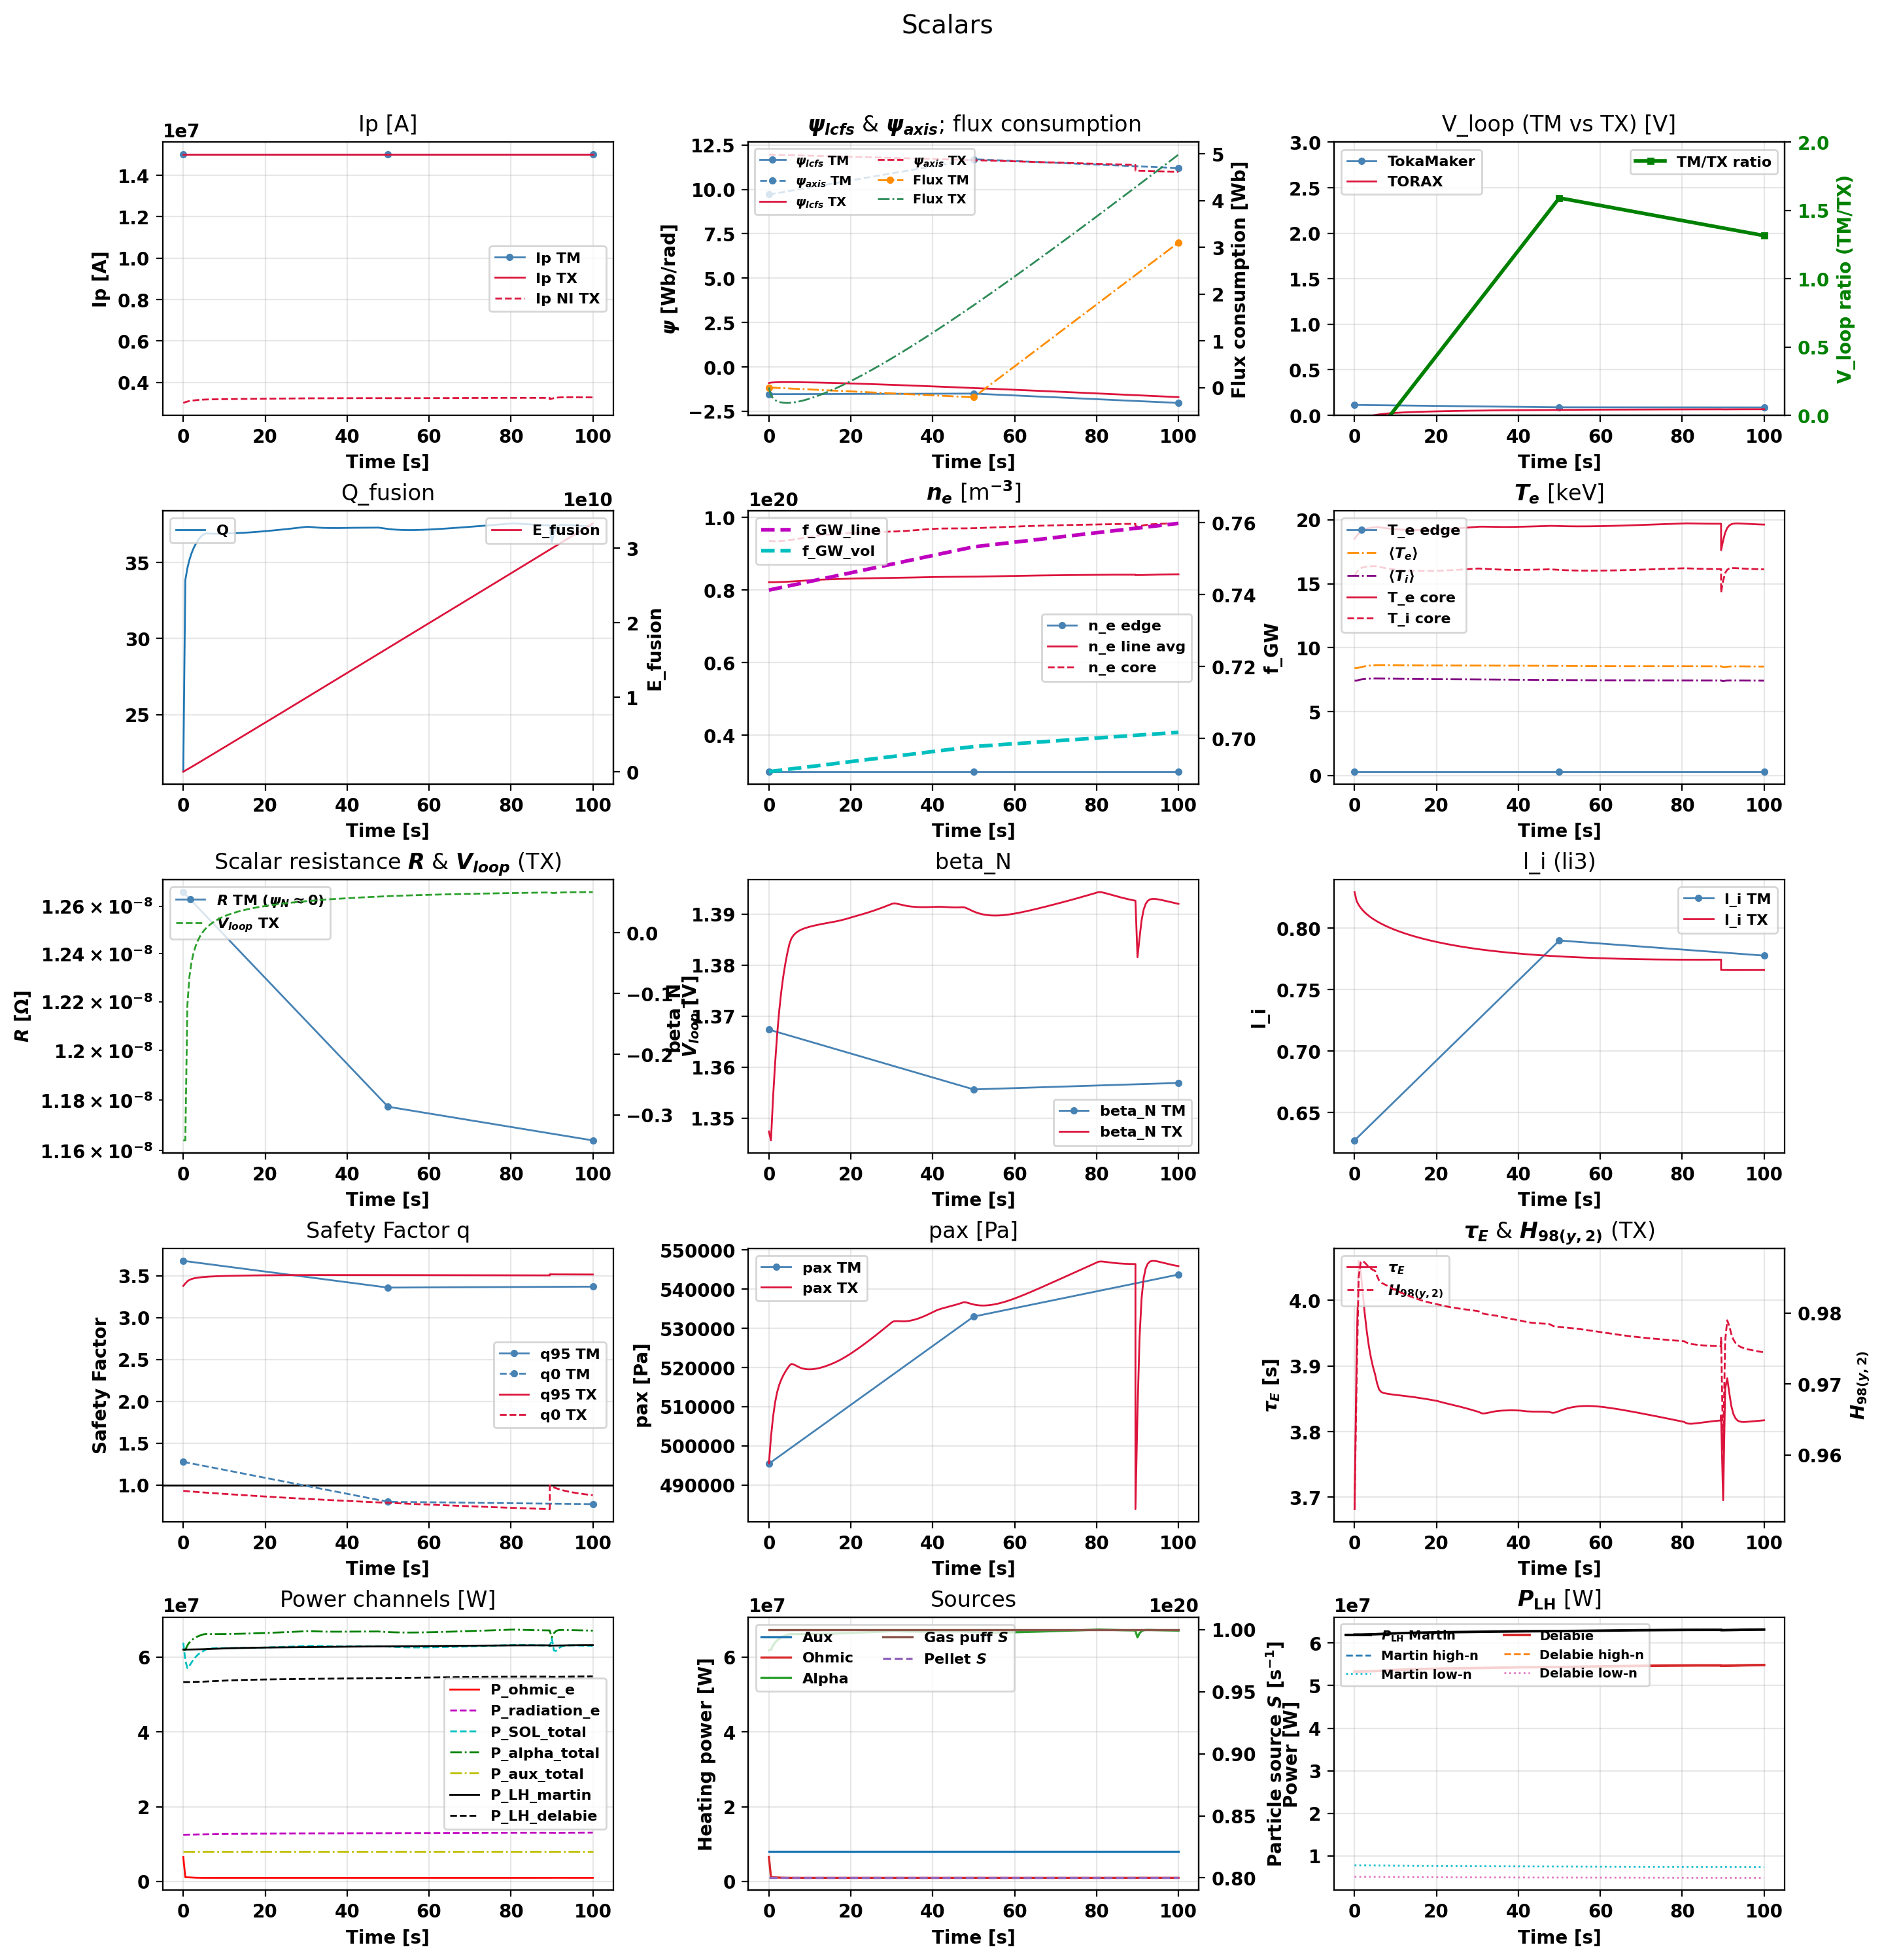

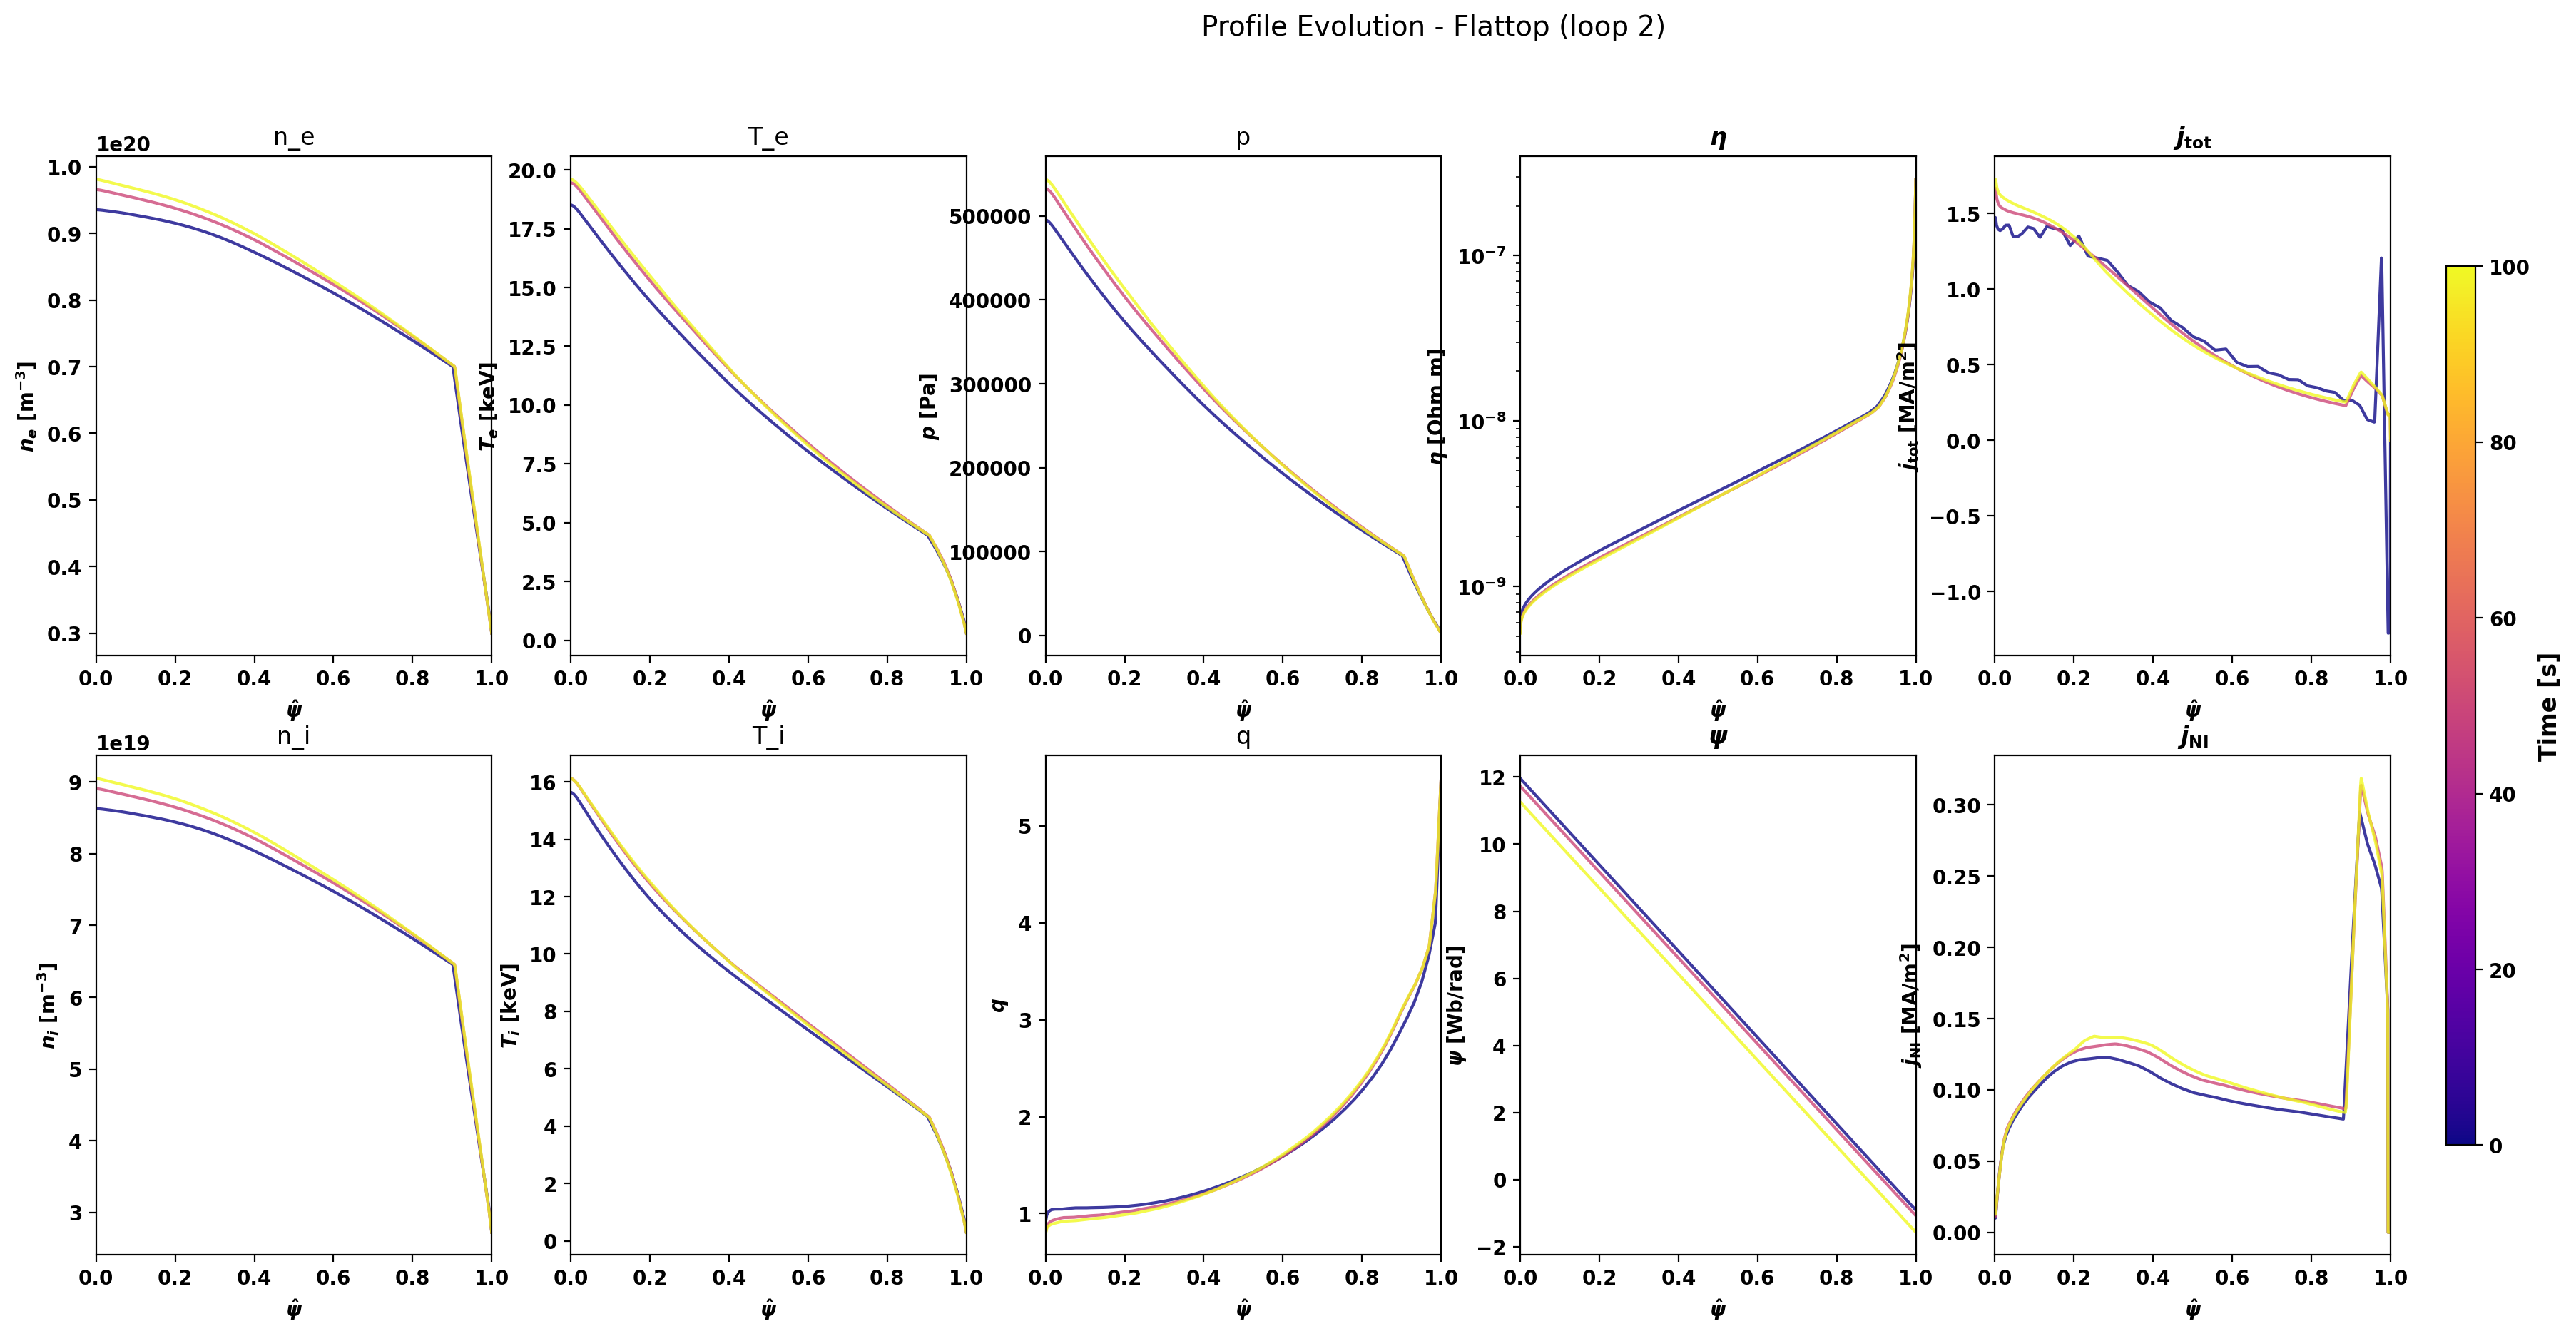

In [15]:
tmtx.summary()
tmtx.plot_scalars()
tmtx.plot_profile_evolution()
tmtx.make_movie(notebook_mode=True, speed_factor=10)

# 14. Sweeps

This next section (commented out by default) runs multiple TokaMaker+TORAX simulations each with a different input parameter. We call this a "sweep". Here I demonstrate how to sweep the $Z_{eff}$. To sweep other variables, replace `tmtx.set_plasma_composition` with the `set` function above that you want to change. This will update that input to TM+TX and leave the others alone.

The TokaMaker_TORAX object is already set up, so we only have to modify the specific input we are interested in and run the simulation. I will extract the profiles and scalars I am interested at the end of each simulation. You can save the `_state` and `_data_tree` objects from each simulation but these are large and you might have memory issues.

In [16]:
# Helper functions for extracting final profiles and scalars from TMTX results

# dt = tmtx._data_tree is the TORAX output object
# var_name = name of scalar or profile variable. For a list of available variables see the TORAX documentation:
# https://torax.readthedocs.io/en/latest/output.html
def get_scalar(dt, var_name, scale=1.0):
    try:
        da = getattr(dt.scalars, var_name).isel(time=-1)
        return da.values * scale
    except Exception:
        return None


def get_profile(dt, var_name, scale=1.0):
    try:
        da = getattr(dt.profiles, var_name).isel(time=-1)
        coord_name = da.dims[0] if da.dims else None
        if coord_name is None:
            return np.arange(da.size), da.values * scale
        return da.coords[coord_name].values, da.values * scale
    except Exception:
        return None, None

In [17]:
# The variable being swept is Z_eff, which is a proxy for how much impurity is in the plasma, in this case Neon.

SWEEP_VAR = [1.5, 2.0, 2.5, 3.0, 3.5]
var_name = 'Z_eff'

# Example of another sweep: fueling rate for gas puff and pellets.
# FUELING_SWEEP = [0.5e20, 1.0e20, 2.0e20, 5.0e20]  # total fueling rate in particles/s
# var_name = 'fueling_rate'

scalar_results = [ # (TORAX variable name, scale factor, label for plotting)
    ("Q_fusion", 1.0, "$Q$"),
    ("P_fusion", 1.0e-6, "$P_{fusion}$ [MW]"),
    ("P_radiation_e", 1.0e-6, "$P_{rad,e}$ [MW]"),
    ("H98", 1.0, "$H_{98}$"),
    ("li3", 1.0, "$l_i$"),
    ("beta_N", 1.0, r"$\beta_N$"),

]

profile_results = [ # (TORAX variable name, scale factor, label for plotting)
    ("n_e", 1.0, r"$n_e$ [m$^{-3}$]"),
    ("n_impurity", 1.0, r"$n_{impurity}$ [m$^{-3}$]"),
    ("p_impurity_radiation_e", 1.0e-6, "$P_{rad, impurity}$ [MW]"),
    ("T_e", 1.0, "$T_e$ [keV]"),
    ("T_i", 1.0, "$T_i$ [keV]"),
    ("pressure_thermal_total", 1.0e-3, "$p$ [kPa]"),
    ("j_total", 1.0, r"$j_{tot}$ [MA/m$^2$]"),
    ("q", 1.0, "$q$"),
]

sweep_results = []
sweep_t0 = perf_counter()

for var in SWEEP_VAR:
    print(f'\n=== Running with {var_name} = {var:.2f} ===\n')
    tmtx.set_plasma_composition(
        main_ion={'D': 0.50, 'T': 0.50},
        impurity='Ne',
        Zeff=var,
    )

    # Example of sweeping fueling: (uncomment the lines below and comment set_plasma_composition)
    # tmtx.set_fueling(
    #     gas_puff_S_total={0: var},
    #     gas_puff_decay_length=0.10,
    #     pellet_S_total={0: var},
    #     pellet_deposition_location=0.2,
    #     pellet_width=0.20,)

    tmtx.fly(
        max_loop=2,
        output_mode=False,
        t_ave_toggle='on',
        t_ave_window=25.0,
        steady_state_mode=True,
    )

    dt = tmtx._data_tree

    scalar_values = {}
    for s_name, s_scale, _s_label in scalar_results:
        val = get_scalar(dt, s_name, scale=s_scale)
        scalar_values[s_name] = np.nan if val is None else float(np.asarray(val).squeeze())

    profile_values = {}
    for p_name, p_scale, _p_label in profile_results:
        rho, vals = get_profile(dt, p_name, scale=p_scale)
        profile_values[p_name] = {
            'rho': None if rho is None else np.asarray(rho, dtype=float),
            'values': None if vals is None else np.asarray(vals, dtype=float),
        }

    sweep_results.append({
        var_name: var,
        'scalars': scalar_values,
        'profiles': profile_values,
    })

sweep_elapsed_s = perf_counter() - sweep_t0
print(f"\nTotal sweep time: {sweep_elapsed_s:.1f} s ({sweep_elapsed_s/60.0:.2f} min)")


=== Running with Z_eff = 1.50 ===

  Log file: /Users/fsheehan/github/TokaMaker_TORAX_project/TokaMaker_TORAX_log_tmp.log

 TokaMaker_TORAX  
 run_name = tmp | t=[0.0, 100.0] s | 3 timepoints | dt=0.5 s | max_loop=2

  Initial TORAX relax


Simulating (t=1.00000): 100%|██████████| 100/100 [00:00<00:00, 2031.11it/s]



  Loop 1
  TORAX: running simulation...


Simulating (t=100.00000): 100%|██████████| 100/100 [00:04<00:00, 21.70it/s]


  TORAX: done (cflux=3.0800 Wb)
  TokaMaker: solving 3 equilibria...


...

  TokaMaker: 3/3 solved (cflux=8.1872 Wb)
	TM summary: 3/3 solved. Levels: raw tx profs: 3.
  Loop 1 result: conv_err=0.000% | TX-TM diff=38.7004% | cflux_TX=5.0187 Wb | cflux_TM=8.1872 Wb

  Loop 2
  TORAX: running simulation...


Simulating (t=100.00000): 100%|██████████| 100/100 [00:03<00:00, 26.26it/s]


  TORAX: done (cflux=6.4287 Wb)
  TokaMaker: solving 3 equilibria...


  TM loop 2: 100%|██████████| 3/3 [00:09<00:00,  3.17s/solve], t=100.00s OK(L0)

  TokaMaker: 3/3 solved (cflux=7.2838 Wb)
	TM summary: 3/3 solved. Levels: raw tx profs: 2, sign_flip: 1.
  Loop 2 result: conv_err=28.094% | TX-TM diff=11.7403% | cflux_TX=6.4287 Wb | cflux_TM=7.2838 Wb

  Max loop index (2) reached (err=28.094%)

  Loop   cflux TX [Wb]    cflux TM [Wb]    TX-TM diff %  
  ----------------------------------------------------
  1      5.0187           8.1872           38.7004       
  2      6.4287           7.2838           11.7403       
  Total sim time: 0m 28.3s
  Log file: /Users/fsheehan/github/TokaMaker_TORAX_project/TokaMaker_TORAX_log_tmp.log

Total sweep time: 137.2 s (2.29 min)


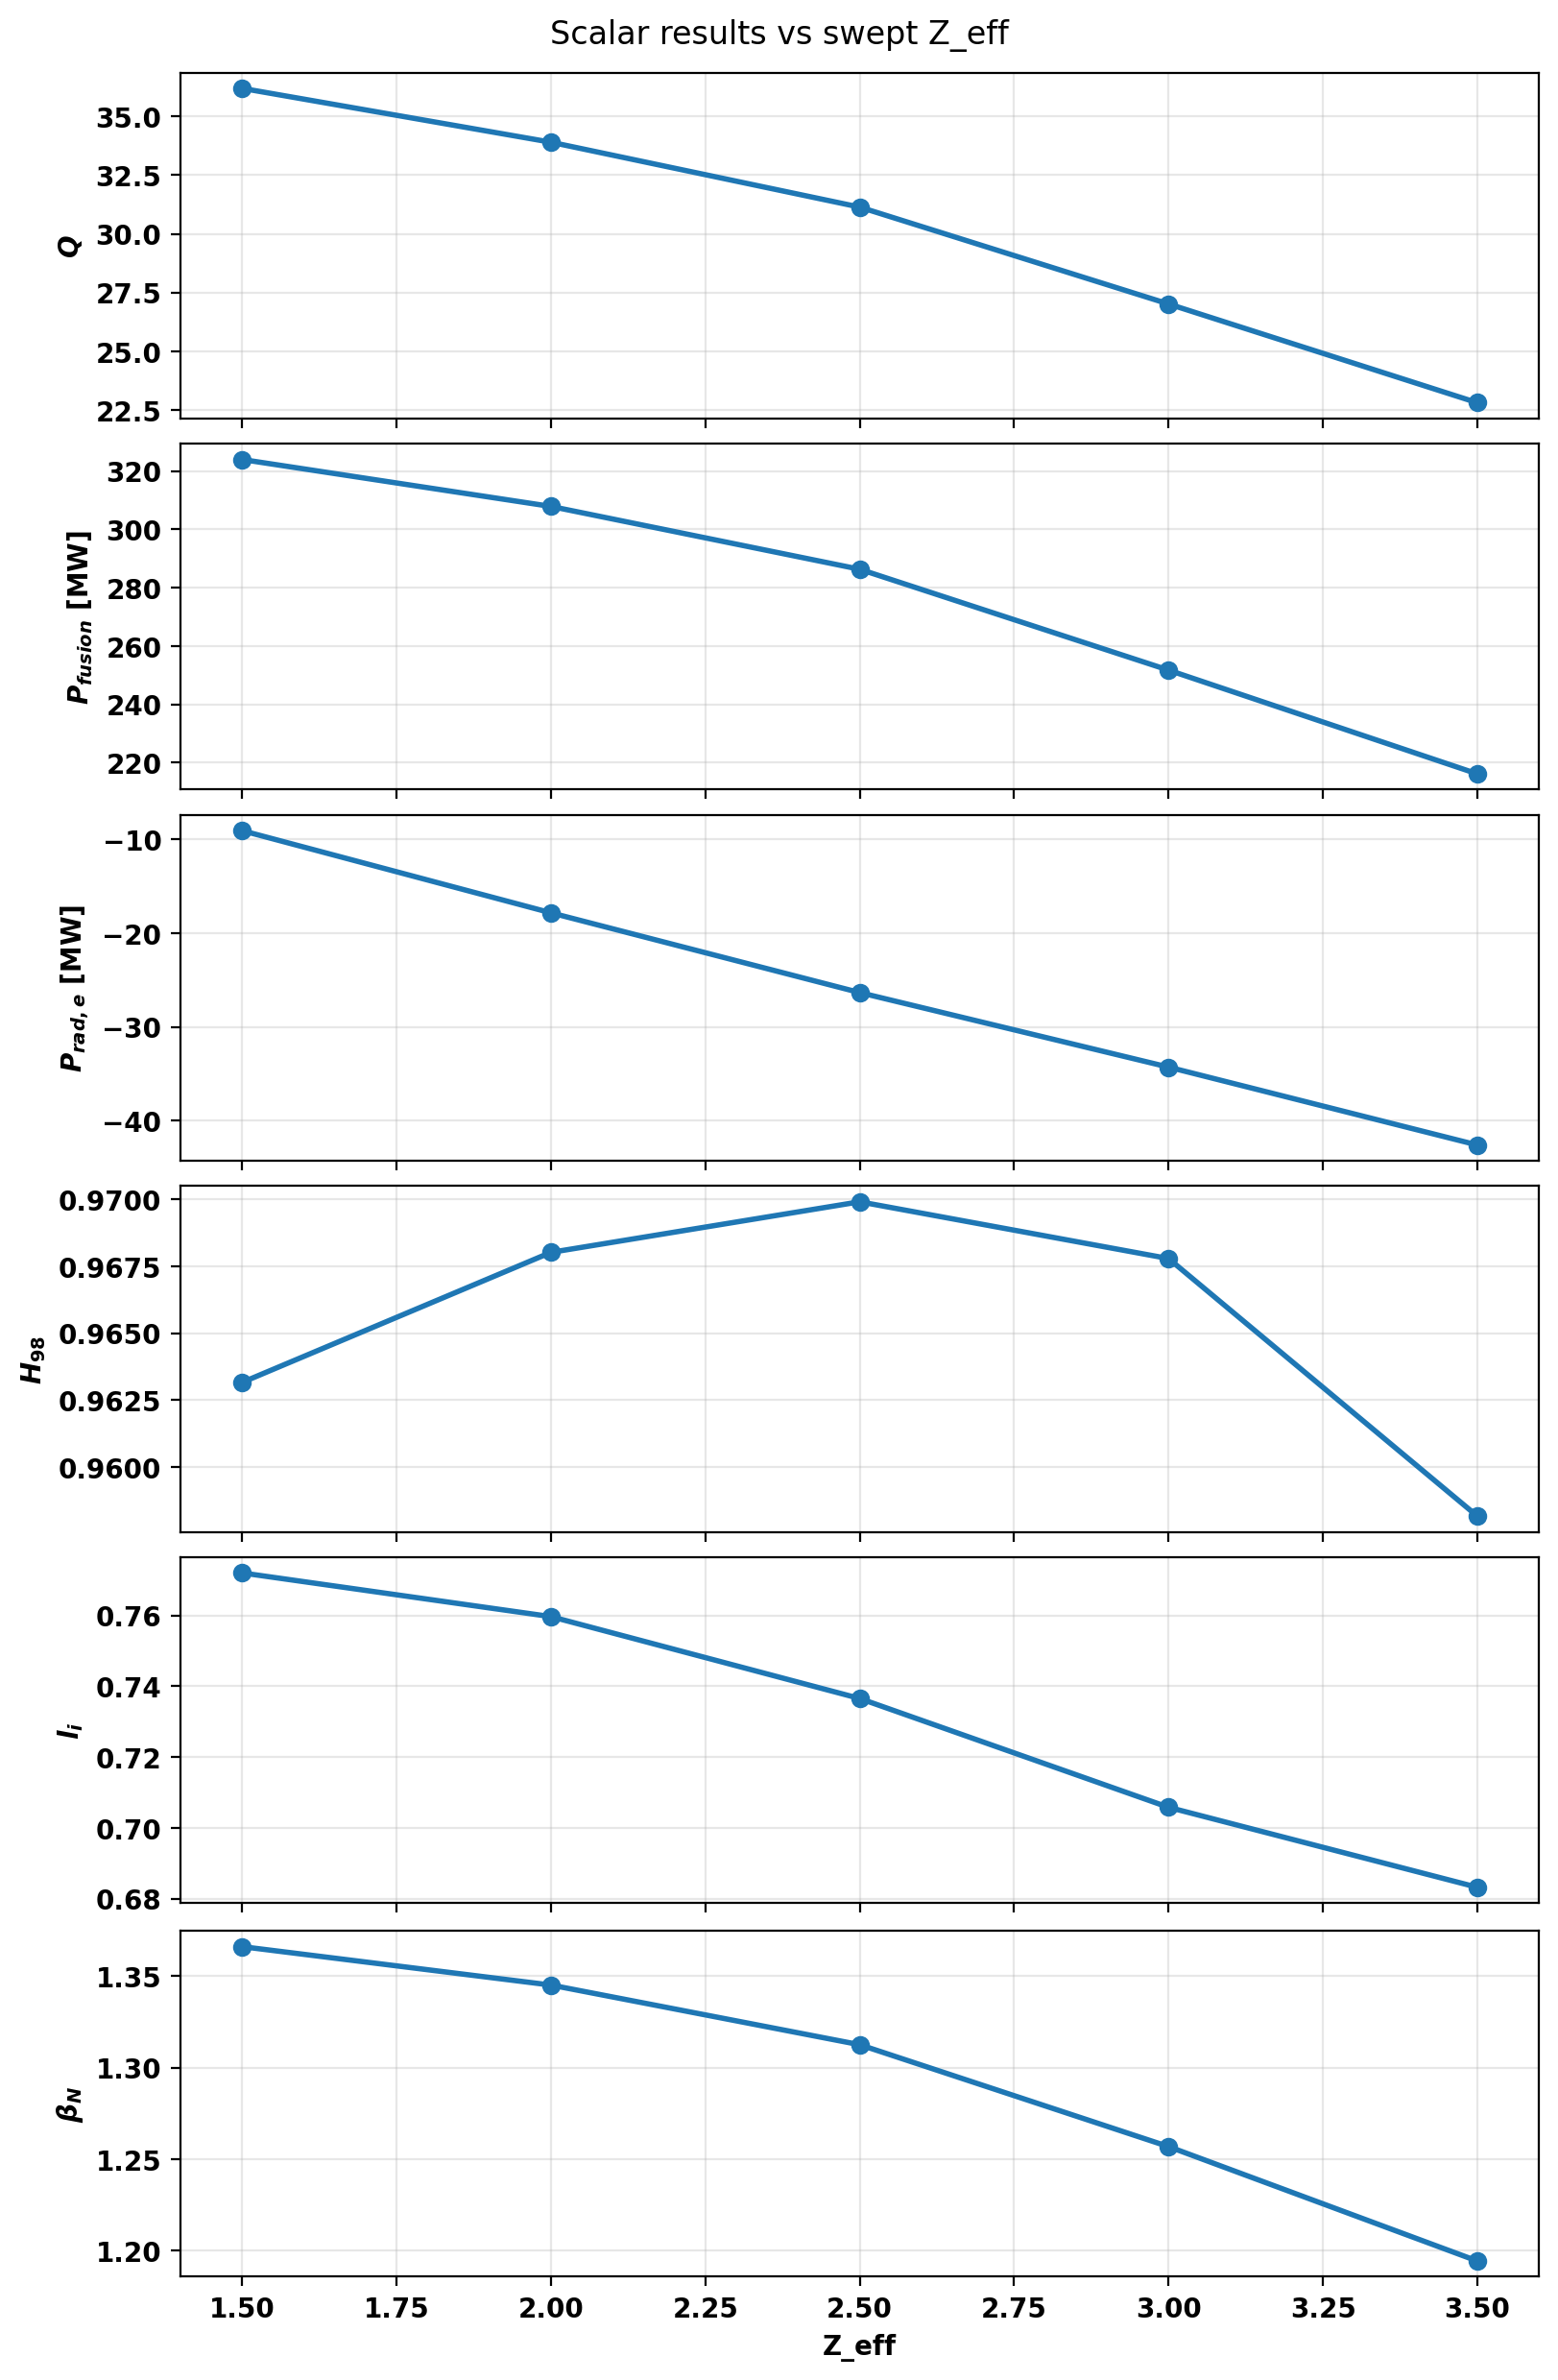

In [18]:
sweep_x = np.asarray([result[var_name] for result in sweep_results], dtype=float)

fig, axes = plt.subplots(len(scalar_results), 1, sharex=True, figsize=(8, 12), constrained_layout=True)
fig.suptitle(f'Scalar results vs swept {var_name}', y=1.02)

for ax, (s_name, _s_scale, s_label) in zip(np.atleast_1d(axes), scalar_results):
    y_values = np.asarray([result['scalars'][s_name] for result in sweep_results], dtype=float)
    ax.plot(sweep_x, y_values, marker='o')
    ax.set_ylabel(s_label)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel(var_name)
plt.show()

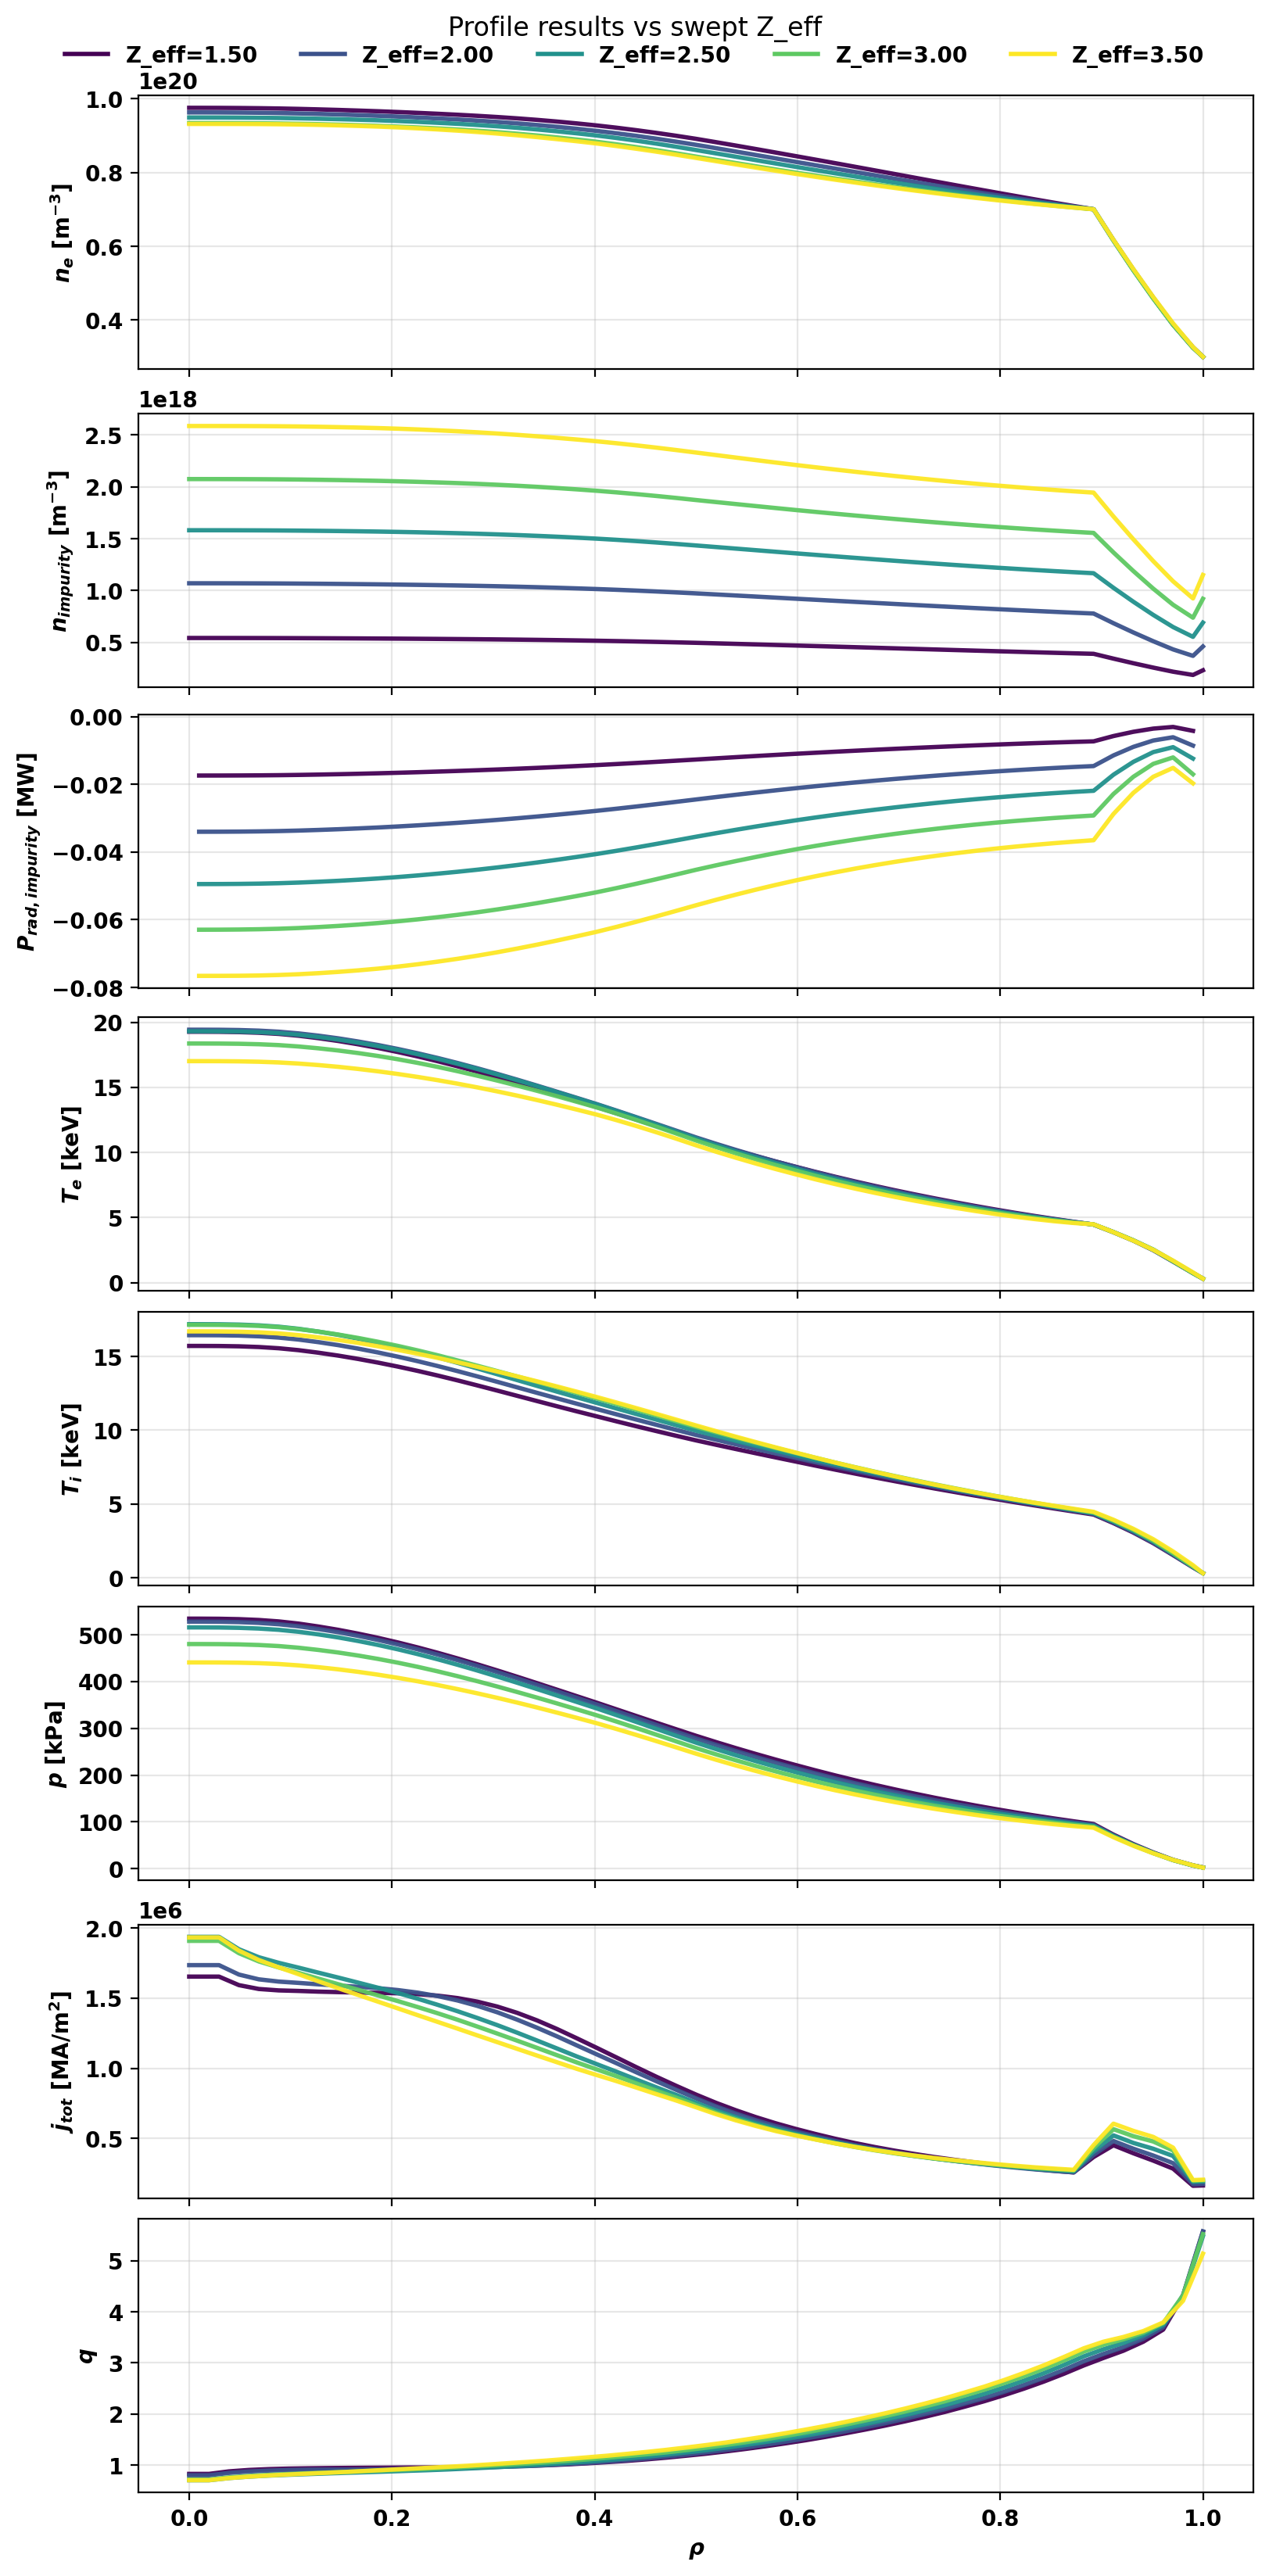

In [19]:
colors = plt.cm.viridis(np.linspace(0.0, 1.0, len(sweep_results)))
fig, axes = plt.subplots(len(profile_results), 1, sharex=True, figsize=(8, 16), constrained_layout=True)
fig.suptitle(f'Profile results vs swept {var_name}', y=1.02)

for ax, (p_name, _p_scale, p_label) in zip(np.atleast_1d(axes), profile_results):
    for result, color in zip(sweep_results, colors):
        profile_data = result['profiles'][p_name]
        rho = profile_data['rho']
        values = profile_data['values']
        if rho is None or values is None:
            continue
        ax.plot(rho, values, color=color, alpha=0.95)
    ax.set_ylabel(p_label)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel(r'$\rho$')
legend_handles = [
    Line2D([0], [0], color=color, lw=2, label=f'{var_name}={val:.2f}')
    for color, val in zip(colors, sweep_x)
]
fig.legend(handles=legend_handles, loc='upper center', ncol=min(5, len(legend_handles)), frameon=False, bbox_to_anchor=(0.5, 1.016))
plt.show()